# Compute Dowker persistent homology
* Due to the computational speed, we use a down-sampled version of the pointclouds.
* The downsampled pointclouds can be found in `/data/downsampled_pointcloud`


In [1]:
using Pkg
Pkg.activate("../.")
Pkg.instantiate()

  Activating project at `~/Documents/lung_ECM_TDA_new`


In [2]:
include("../src/dowker_persistence.jl")
using .Dowker

WebIO._IJuliaInit()

In [3]:
include("../src/ECM_TDA.jl")
using .ECM_TDA

include("../src/Eirene_var.jl")
using .Eirene_var
using Ripserer

Error processing line 1 of /Users/hyoon-24/anaconda3/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 186, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


In [48]:
using JLD2
using CSV
using DataFrames
using DelimitedFiles
using Plots
using Plots.PlotMeasures

# parameters for point cloud plotting 
p_markersize = 5
p_markerstrokewidth = 0.1
p_imagesize = (300, 300)

(300, 300)

In [45]:
get_PD0_max2(PD_dict) = maximum([sort(hcat(PD_dict[i]...), dims = 1)[end-1] for (i,v) in PD_dict if v != reshape(Array([0.0]), 1, 1) ])

get_PD0_max2 (generic function with 1 method)

# 1. Dowker persistence diagram computation on an example ROI

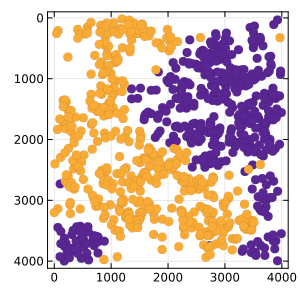

In [9]:
# load points
celltype1 = Array(CSV.read("../data/downsampled_pointcloud/cancer/ROI1.csv", DataFrame))
celltype2 = Array(CSV.read("../data/downsampled_pointcloud/leukocytes/ROI1.csv", DataFrame));

# plot the two cell types
p = scatter(celltype1[:,1], celltype1[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 #ticks = [],
                 c =  "#592693" # purple
                 )
scatter!(p, celltype2[:,1], celltype2[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 #ticks = [],
                 c = "#FAAB36" # orange
                 )
plot(p, aspect = :equal, size = p_imagesize,  
        background_color=:transparent, foreground_color=:black
        )

In [10]:
# compute Dowker persistence diagram
DPD0, DPD1, _ = Dowker.compute_Dowker(celltype1, celltype2);

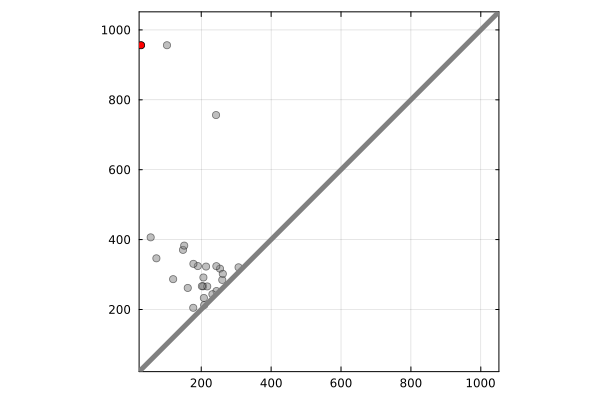

In [ ]:
# plot the dowker persistence diagram 
Dowker.plot_PD(DPD0)

# 2. Compute Dowker persistence diagrams for all ROIs, all pairs among: ECM, cancer cells, leukocytes

## 2(a) Between cancer and leukocytes

In [29]:
cell_dir = "../data/downsampled_pointcloud/"
csv_files = [item for item in walkdir(cell_dir * "cancer/")][1][3:end][1]
for (idx, file) in enumerate(csv_files)

    # load data 
    cells_cancer = Array(CSV.read(cell_dir * "cancer/" * file, DataFrame));
    cells_leukocytes = Array(CSV.read(cell_dir * "leukocytes/" * file, DataFrame));

    W_barcode0, W_barcode1, _ = Dowker.compute_Dowker(cells_cancer, cells_leukocytes)
   
    # save
    if W_barcode0 == nothing
        writedlm("Dowker_persistent_homology_outputs/cancer_leukocytes/persistence_diagrams/PD0/" * file, zeros(), ",")    
    else
        writedlm("Dowker_persistent_homology_outputs/cancer_leukocytes/persistence_diagrams/PD0/" * file, W_barcode0, ",")    
    end
    
    if W_barcode1 == nothing
        writedlm("Dowker_persistent_homology_outputs/cancer_leukocytes/persistence_diagrams/PD1/" * file, zeros(), ",")
    else
        writedlm("Dowker_persistent_homology_outputs/cancer_leukocytes/persistence_diagrams/PD1/" * file, W_barcode1, ",")
    end
end

## 2(b) Between ECM and leukocytes

In [ ]:
cell_dir = "../data/downsampled_pointcloud/"
csv_files = [item for item in walkdir(cell_dir * "ECM/")][1][3:end][1]
for (idx, file) in enumerate(csv_files)

    # load sampled cells
    pointcloud_ECM = Array(CSV.read(cell_dir * "ECM/" * file, DataFrame, header = [:x, :y])); # ECM pointcloud files don't have column names, while cancer and leukocyte CSV files do. 
    pointcloud_leukocytes = Array(CSV.read(cell_dir * "leukocytes/" * file, DataFrame));

    W_barcode0, W_barcode1, _ = Dowker.compute_Dowker(pointcloud_ECM, pointcloud_leukocytes)
   
    # save
    if W_barcode0 == nothing
        writedlm("Dowker_persistent_homology_outputs/ECM_leukocytes/persistence_diagrams/PD0/" * file, zeros(), ",")    
    else
        writedlm("Dowker_persistent_homology_outputs/ECM_leukocytes/persistence_diagrams/PD0/" * file, W_barcode0, ",")    
    end
    
    if W_barcode1 == nothing
        writedlm("Dowker_persistent_homology_outputs/ECM_leukocytes/persistence_diagrams/PD1/" * file, zeros(), ",")
    else
        writedlm("Dowker_persistent_homology_outputs/ECM_leukocytes/persistence_diagrams/PD1/" * file, W_barcode1, ",")
    end
end

LoadError: InterruptException:

## 2(c) Between ECM and cancer 

In [ ]:
cell_dir = "../data/downsampled_pointcloud/"
csv_files = [item for item in walkdir(cell_dir * "ECM/")][1][3:end][1]
for (idx, file) in enumerate(csv_files)

    # load sampled cells
    pointcloud_ECM = Array(CSV.read(cell_dir * "ECM/" * file, DataFrame, header = [:x, :y])); # ECM pointcloud files don't have column names, while cancer and leukocyte CSV files do. 
    pointcloud_cancer = Array(CSV.read(cell_dir * "cancer/" * file, DataFrame));

    W_barcode0, W_barcode1, _ = Dowker.compute_Dowker(pointcloud_ECM, pointcloud_cancer)
   
    # save
    if W_barcode0 == nothing
        writedlm("Dowker_persistent_homology_outputs/ECM_cancer/persistence_diagrams/PD0/" * file, zeros(), ",")    
    else
        writedlm("Dowker_persistent_homology_outputs/ECM_cancer/persistence_diagrams/PD0/" * file, W_barcode0, ",")    
    end
    
    if W_barcode1 == nothing
        writedlm("Dowker_persistent_homology_outputs/ECM_cancer/persistence_diagrams/PD1/" * file, zeros(), ",")
    else
        writedlm("Dowker_persistent_homology_outputs/ECM_cancer/persistence_diagrams/PD1/" * file, W_barcode1, ",")
    end
end

# 3. Compute persistence image features from Dowker persistence diagrams

In [39]:
s = "cancer_leukocytes" # choose one of the following: "cancer_leukocytes", "ECM_cancer", "ECM_leukocytes"
dir = "Dowker_persistent_homology_outputs/" * s * "/persistence_diagrams/PD0/"
csv_files = [item for item in walkdir(dir)][1][3:end][1]

# load PD
PD0 = Dict()
PD1 = Dict()
for (idx, file) in enumerate(csv_files)
    ROI = file[1:end-4]
    PD0[ROI] = readdlm("Dowker_persistent_homology_outputs/" * s * "/persistence_diagrams/PD0/" * file, ',')
    
    # check if the W1 is empty
    if filesize("Dowker_persistent_homology_outputs/" * s * "/persistence_diagrams/PD1/" * file) == 0
        PD1[ROI] = reshape(Array([0.0]), 1, 1)
    else
        PD1[ROI] = readdlm("Dowker_persistent_homology_outputs/" * s * "/persistence_diagrams/PD1/" * file, ',')
    end
end

# convert to Ripser PD
PH0 = Dict(k => ECM_TDA.array_to_ripsererPD(v) for (k,v) in PD0 if v != reshape(Array([0.0]), 1, 1))
PH1 = Dict(k => ECM_TDA.array_to_ripsererPD(v) for (k,v) in PD1 if v != reshape(Array([0.0]), 1, 1))

# compute PI
PI0 = ECM_TDA.compute_PI(PH0)
PI1 = ECM_TDA.compute_PI(PH1);


In [43]:
# save the PDs and PIs as JLD2 files 
save("Dowker_persistent_homology_outputs/" * s * "/PD.jld2", 
"PD0", PD0,
"PD1", PD1)

save("Dowker_persistent_homology_outputs/" * s * "/PI.jld2",
"PI0", PI0,
"PI1", PI1
)

In [49]:
### save plots of persistence diagrams and persistence images

# compute maximum PD values (for plotting)
PD0_max = get_PD0_max2(PD0) # not a typo. This is because Dowker PD0 doesn't just end with one connected component
PD1_max = get_PD1_max(PD1);

output_dir = "Dowker_persistent_homology_outputs/" * s 
# dim 0
for k in keys(PD0)
    p = Dowker.plot_PD(PD0[k], pd_min = 0, pd_max = PD0_max, frame = :box)
    savefig(output_dir * "/persistence_diagrams/PD0_figures/" * k * ".png")
end

# dim 1
for k in keys(PD1)
    p = Dowker.plot_PD(PD1[k], pd_min = 0, pd_max = PD1_max, frame = :box)
    savefig(output_dir * "/persistence_diagrams/PD1_figures/" * k * ".png")
end

### save persistence images
# dim 0
for k in keys(PI0)
    p = heatmap(PI0[k], rightmargin = 10mm, size = (380, 300))
    savefig(output_dir * "/persistence_images/PI0_figures/" * k * ".png")
end

# dim 1
for k in keys(PI1)
    p = heatmap(PI1[k], rightmargin = 10mm, size = (380, 300))
    savefig(output_dir * "/persistence_images/PI1_figures/" * k * ".png")
end